In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import scipy.stats as stats
import statsmodels.api as sm 

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor 
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [4]:
df_gefiltert = pd.read_pickle('verarbeitete_daten.pkl')

## Hypothese (Gesamtsignifikanz des Modells):

- H0: 
    - Die Gesamtheit der ausgewählten Prädiktoren (is_verified, account_category, follower_count etc.) hat keinen linearen Einfluss auf likes_log.
- H1: 
    - Mindestens einer der ausgewählten Prädiktoren hat einen signifikanten linearen Einfluss auf likes_log. 

In [5]:
feature_columns_hypothese = ['follower_count', 'comment_count']

# Account-spezifische Merkmale:
if 'is_verified' in df_gefiltert.columns: feature_columns_hypothese.append('is_verified')
if 'is_professional_account' in df_gefiltert.columns: feature_columns_hypothese.append('is_professional_account')
if 'account_category' in df_gefiltert.columns: feature_columns_hypothese.append('account_category')
if 'is_business_account' in df_gefiltert.columns: feature_columns_hypothese.append('is_business_account') # Auch wenn der Einfluss "leicht negativ" ist, behalten wir es zur Prüfung

# Zeitliche Faktoren:
if 'day_of_week' in df_gefiltert.columns: feature_columns_hypothese.append('day_of_week') 
if 'month' in df_gefiltert.columns: feature_columns_hypothese.append('month')
if 'hour_of_day' in df_gefiltert.columns: feature_columns_hypothese.append('hour_of_day')

# Zusätzliche relevante Metadaten, die oft einen Einfluss haben:
if 'caption_length' in df_gefiltert.columns: feature_columns_hypothese.append('caption_length')
if 'hashtag_count' in df_gefiltert.columns: feature_columns_hypothese.append('hashtag_count')
if 'mention_count' in df_gefiltert.columns: feature_columns_hypothese.append('mention_count')
if 'tagged_user_count' in df_gefiltert.columns: feature_columns_hypothese.append('tagged_user_count')


existing_feature_columns_hypothese = [col for col in feature_columns_hypothese if col in df_gefiltert.columns]
X_hypothese = df_gefiltert[existing_feature_columns_hypothese].copy()
y_hypothese = df_gefiltert['likes_log'].copy()
print("\nAusgewählte Features für X (basierend auf Hypothese):")
X_hypothese.info()


# Identifiziere numerische und kategoriale Spalten in X_hypothese
numerical_cols_hypothese = X_hypothese.select_dtypes(include=np.number).columns.tolist()
categorical_cols_hypothese = X_hypothese.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()


print(f"\nFinale numerische Features für Preprocessing (Hypothese): {numerical_cols_hypothese}")
print(f"Finale kategoriale Features für Preprocessing (Hypothese): {categorical_cols_hypothese}")

# Preprocessing Pipelines
numerical_pipeline_hypo = Pipeline([
    ('scaler', StandardScaler())
])

categorical_pipeline_hypo = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')) 
])

# keine Überschneidungen zwischen numerical_cols und categorical_cols 
common_cols_hypo = list(set(numerical_cols_hypothese) & set(categorical_cols_hypothese))
if common_cols_hypo:
    print(f"WARNUNG: Gemeinsame Spalten in numerical_cols_hypothese und categorical_cols_hypothese gefunden: {common_cols_hypo}")
    for c_col in common_cols_hypo:
        if c_col in numerical_cols_hypothese: numerical_cols_hypothese.remove(c_col)


preprocessor_hypothese = ColumnTransformer([
    ('numerical', numerical_pipeline_hypo, numerical_cols_hypothese),
    ('categorical', categorical_pipeline_hypo, categorical_cols_hypothese)
], remainder='drop')


# Aufteilung in Trainings- und Testsets
X_train_hypo, X_test_hypo, y_train_hypo, y_test_hypo = train_test_split(X_hypothese, y_hypothese, test_size=0.4, random_state=42)

print(f"\nGröße Trainingsdaten X (Hypothese): {X_train_hypo.shape}")
print(f"Größe Testdaten X (Hypothese): {X_test_hypo.shape}")

if X_train_hypo.empty:
    raise ValueError("X_train_hypo ist leer nach dem Splitten. Überprüfe die Daten und Feature-Auswahl.")


Ausgewählte Features für X (basierend auf Hypothese):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1968 entries, 0 to 1967
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   follower_count           1968 non-null   int64 
 1   comment_count            1968 non-null   int64 
 2   is_verified              1968 non-null   bool  
 3   is_professional_account  1968 non-null   bool  
 4   account_category         1766 non-null   object
 5   is_business_account      1968 non-null   bool  
 6   day_of_week              1968 non-null   object
 7   month                    1968 non-null   object
 8   hour_of_day              1968 non-null   int32 
 9   caption_length           1968 non-null   int64 
 10  hashtag_count            1968 non-null   int64 
 11  mention_count            1968 non-null   int64 
dtypes: bool(3), int32(1), int64(5), object(3)
memory usage: 136.6+ KB

Finale numerische Featur

### Funktion zur Zusammenfassung der OLS-Ergebnisse definieren


In [6]:
def summarize_ols_regression_results(results, X_test_data, y_test_data, feature_names=None):
    if results is None:
        print("Modell konnte nicht trainiert werden. Keine Ergebnisse zum Anzeigen.")
        return

    print("OLS Regression Results Summary:")
    print("==============================")
    print(results.summary(xname=feature_names if feature_names else list(X_test_data.columns)))
    print("\nParameterschätzungen (Koeffizienten):")
    print("------------------------------------")
    print(results.params)

    # Vorhersagen auf Testdaten
    y_pred_test = results.predict(X_test_data)

    # Metriken für Testdaten (auf der Skala von log-Likes)
    mse_test = mean_squared_error(y_test_data, y_pred_test)
    mae_test = mean_absolute_error(y_test_data, y_pred_test)
    r2_test_sm = r2_score(y_test_data, y_pred_test)

    print("\n--- Metriken auf Testdaten (log-transformierte Likes) ---")
    print(f"Mean Squared Error (MSE): {mse_test:.4f}")
    print(f"Mean Absolute Error (MAE): {mae_test:.4f}")
    print(f"R-squared (R²): {r2_test_sm:.4f} (berechnet für Testdaten)")
    print(f"AIC: {results.aic:.2f}")
    print(f"BIC: {results.bic:.2f}")

    # Rücktransformation für interpretierbare Metriken
    target_variable_name = y_test_data.name if hasattr(y_test_data, 'name') else 'likes_log' # Standardname falls unbekannt

    if target_variable_name == 'likes_log':
        y_test_orig = np.expm1(y_test_data)
        y_pred_test_orig = np.expm1(y_pred_test)
        y_pred_test_orig[y_pred_test_orig < 0] = 0 

        print("\n--- Metriken auf Testdaten (Original-Skala der Likes) ---")
        print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_orig, y_pred_test_orig):.2f} Likes")
        print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test_orig, y_pred_test_orig)):.2f} Likes")
        print(f"R-squared (R²) auf Originalskala: {r2_score(y_test_orig, y_pred_test_orig):.4f}")

    # Visualisierung der Vorhersagen vs. tatsächliche Werte
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test_data, y_pred_test, alpha=0.5, label='Vorhersagen')
    plt.plot([y_test_data.min(), y_test_data.max()], [y_test_data.min(), y_test_data.max()], '--', color='red', lw=2, label='Perfekte Vorhersage')
    plt.xlabel(f"Tatsächliche {target_variable_name}")
    plt.ylabel(f"Vorhergesagte {target_variable_name}")
    plt.title(f"Tatsächliche vs. Vorhergesagte {target_variable_name} (Testdaten - OLS)")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Residuenplot
    residuals = y_test_data.reset_index(drop=True) - pd.Series(y_pred_test).reset_index(drop=True) # Stelle Index-Konsistenz sicher
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=y_pred_test, y=residuals, alpha=0.5)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel("Vorhergesagte Werte")
    plt.ylabel("Residuen (Tatsächlich - Vorhergesagt)")
    plt.title("Residuenplot")
    plt.grid(True)
    plt.show()

### Training eines auf der Hypothese basierenden Modells (Lineare Regression mit statsmodels) 

In [7]:
print("Starte Daten-Preprocessing für das hypothesenbasierte OLS-Modell...")
try:
    X_train_processed_hypo_np = preprocessor_hypothese.fit_transform(X_train_hypo)
    X_test_processed_hypo_np = preprocessor_hypothese.transform(X_test_hypo)
    print("Daten-Preprocessing abgeschlossen.")

    transformed_feature_names_hypo = []
    
    # Numerische Features
    num_transformer_hypo = preprocessor_hypothese.named_transformers_.get('numerical')
    if num_transformer_hypo and numerical_cols_hypothese: # numerical_cols_hypothese ist die Liste der numerischen Spalten vor OHE
        # Die Namen bleiben nach Skalierung/Imputation gleich
        transformed_feature_names_hypo.extend(numerical_cols_hypothese)

    # One-Hot-kodierte Features
    cat_transformer_hypo = preprocessor_hypothese.named_transformers_.get('categorical')
    if cat_transformer_hypo and categorical_cols_hypothese: # categorical_cols_hypothese ist die Liste der kategorialen Spalten vor OHE
        onehot_step_hypo = cat_transformer_hypo.named_steps.get('onehot')
        if onehot_step_hypo and hasattr(onehot_step_hypo, 'get_feature_names_out'):
            try:
                # Übergebe die ursprünglichen kategorialen Spaltennamen an get_feature_names_out
                onehot_feature_names_hypo = onehot_step_hypo.get_feature_names_out(categorical_cols_hypothese)
                transformed_feature_names_hypo.extend(list(onehot_feature_names_hypo))
            except Exception as e_gn:
                print(f"Fehler beim Holen der OHE Feature Namen mit get_feature_names_out: {e_gn}")
                pass 
        else:
            if categorical_cols_hypothese:
                 print("Warnung: Konnte Feature-Namen von OneHotEncoder nicht automatisch beziehen (get_feature_names_out nicht verfügbar/erfolgreich).")

    # DataFrame erstellen
    # Wenn die Feature-Namen nicht korrekt extrahiert werden konnten, ist es besser,
    # die Anzahl der Spalten direkt vom NumPy-Array zu nehmen und generische Namen zu verwenden.
    if X_train_processed_hypo_np.shape[1] == len(transformed_feature_names_hypo) and transformed_feature_names_hypo:
        X_train_processed_hypo_df = pd.DataFrame(X_train_processed_hypo_np, columns=transformed_feature_names_hypo, index=X_train_hypo.index)
        X_test_processed_hypo_df = pd.DataFrame(X_test_processed_hypo_np, columns=transformed_feature_names_hypo, index=X_test_hypo.index)
        print(f"Verwende {len(transformed_feature_names_hypo)} extrahierte Feature-Namen.")
    else:
        num_cols_after_transform = X_train_processed_hypo_np.shape[1]
        print(f"Warnung: Anzahl der extrahierten Feature-Namen ({len(transformed_feature_names_hypo)}) stimmt nicht mit der Spaltenanzahl der prozessierten Daten ({num_cols_after_transform}) überein oder Namen sind leer. Verwende generische Namen.")
        fallback_cols = [f"feature_{i}" for i in range(num_cols_after_transform)]
        X_train_processed_hypo_df = pd.DataFrame(X_train_processed_hypo_np, columns=fallback_cols, index=X_train_hypo.index)
        X_test_processed_hypo_df = pd.DataFrame(X_test_processed_hypo_np, columns=fallback_cols, index=X_test_hypo.index)
        transformed_feature_names_hypo = fallback_cols # Wichtig für die Summary später


    # eine Konstante für den Intercept 
    X_train_ols_hypo = sm.add_constant(X_train_processed_hypo_df.reset_index(drop=True), has_constant='add')
    X_test_ols_hypo = sm.add_constant(X_test_processed_hypo_df.reset_index(drop=True), has_constant='add')

    print("\nStarte OLS-Modelltraining (hypothesenbasiert)...")
    ols_model_hypo = sm.OLS(y_train_hypo.reset_index(drop=True), X_train_ols_hypo)
    ols_results_hypo = ols_model_hypo.fit()
    print("OLS-Modelltraining (hypothesenbasiert) abgeschlossen.")

except Exception as e:
    print(f"Fehler während des Preprocessings oder OLS-Modelltrainings (hypothesenbasiert): {e}")


Starte Daten-Preprocessing für das hypothesenbasierte OLS-Modell...
Daten-Preprocessing abgeschlossen.
Verwende 51 extrahierte Feature-Namen.

Starte OLS-Modelltraining (hypothesenbasiert)...
OLS-Modelltraining (hypothesenbasiert) abgeschlossen.


### Evaluierung des hypothesenbasierten Modells (OLS-Regression) 


Starte OLS-Modellevaluierung (hypothesenbasiert)...
OLS Regression Results Summary:
                            OLS Regression Results                            
Dep. Variable:              likes_log   R-squared:                       0.680
Model:                            OLS   Adj. R-squared:                  0.666
Method:                 Least Squares   F-statistic:                     47.03
Date:                Mon, 26 May 2025   Prob (F-statistic):          7.12e-241
Time:                        19:10:21   Log-Likelihood:                -2459.0
No. Observations:                1180   AIC:                             5022.
Df Residuals:                    1128   BIC:                             5286.
Df Model:                          51                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
--------------

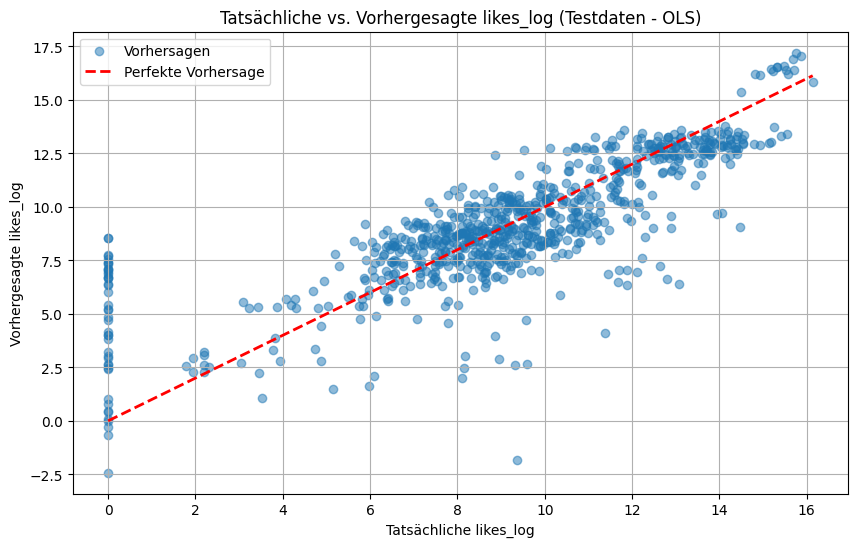

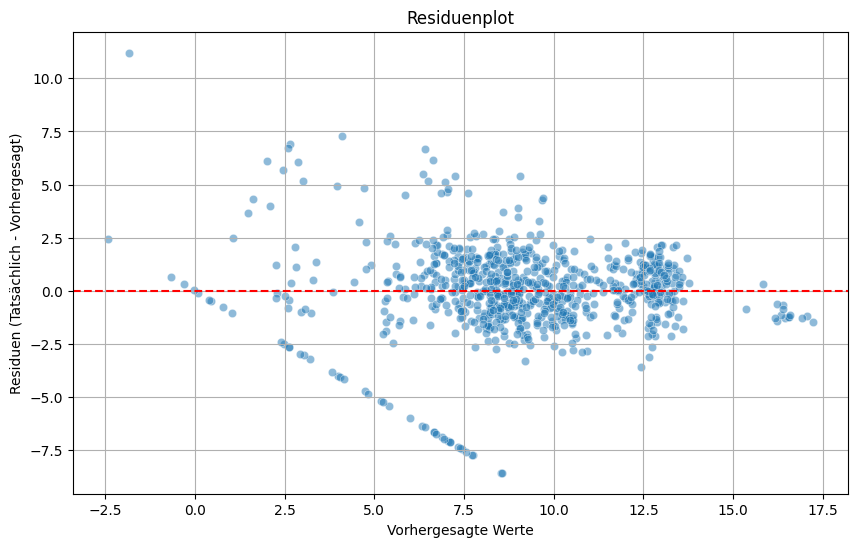

In [8]:
print("\nStarte OLS-Modellevaluierung (hypothesenbasiert)...")
if 'ols_results_hypo' in locals() and ols_results_hypo is not None and \
   'X_test_ols_hypo' in locals() and X_test_ols_hypo is not None and \
   'y_test_hypo' in locals() and 'transformed_feature_names_hypo' in locals():
    summarize_ols_regression_results(ols_results_hypo, X_test_ols_hypo, y_test_hypo, feature_names=list(X_test_ols_hypo.columns))
else:
    print("Keine OLS-Ergebnisse (hypothesenbasiert), Testdaten oder Feature-Namen zum Evaluieren vorhanden. Überprüfe den Trainingsschritt.")